In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
import math
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data Loading

In [2]:
# Load loan-level MBS data
df = pd.read_csv(r"C:\Users\sbalodi\Desktop\final_cph_data.csv")
df1 = pd.DataFrame(df)
df1.head()

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
0,F14Q10000011,794,201403,202902,I,73,45,62000,180,201402,62000.0,0,0,4.25,NaN
1,F14Q10000011,794,201403,202902,I,73,45,62000,180,201403,62000.0,0,1,4.25,NaN
2,F14Q10000011,794,201403,202902,I,73,45,62000,180,201404,62000.0,0,2,4.25,NaN
3,F14Q10000011,794,201403,202902,I,73,45,62000,180,201405,61000.0,0,3,4.25,NaN
4,F14Q10000011,794,201403,202902,I,73,45,62000,180,201406,61000.0,0,4,4.25,NaN


# Exploratory Data Analysis and Preprocessing

In [3]:
df1.shape

(23248344, 15)

In [4]:
single_loan_df = df1[df1['Loan_ID'] == 'F14Q10000011']
single_loan_df

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
0,F14Q10000011,794,201403,202902,I,73,45,62000,180,201402,62000.00,0,0,4.25,NaN
1,F14Q10000011,794,201403,202902,I,73,45,62000,180,201403,62000.00,0,1,4.25,NaN
2,F14Q10000011,794,201403,202902,I,73,45,62000,180,201404,62000.00,0,2,4.25,NaN
3,F14Q10000011,794,201403,202902,I,73,45,62000,180,201405,61000.00,0,3,4.25,NaN
4,F14Q10000011,794,201403,202902,I,73,45,62000,180,201406,61000.00,0,4,4.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,F14Q10000011,794,201403,202902,I,73,45,62000,180,202002,19813.88,0,72,4.25,17.0
73,F14Q10000011,794,201403,202902,I,73,45,62000,180,202003,13417.64,0,73,4.25,11.0
74,F14Q10000011,794,201403,202902,I,73,45,62000,180,202004,12998.75,0,74,4.25,10.0
75,F14Q10000011,794,201403,202902,I,73,45,62000,180,202005,12578.38,0,75,4.25,10.0


In [5]:
df1.describe()

,Credit Score,First Payment Date,Maturity Date,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV)
count,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.324834e+07,2.050245e+07
mean,7.500549e+02,2.017938e+05,2.044527e+05,7.393260e+01,8.603832e+01,2.378500e+05,3.199884e+02,2.020517e+05,2.157762e+05,3.164580e+01,4.143918e+00,1.322874e+02
std,1.306070e+02,2.854700e+02,7.047455e+02,1.870822e+01,2.168078e+02,1.344903e+05,7.309492e+01,2.812477e+02,1.334747e+05,2.662339e+01,1.014367e+00,2.599507e+02
min,3.000000e+02,2.014020e+05,2.022030e+05,3.000000e+00,1.000000e+00,1.000000e+04,8.500000e+01,2.014020e+05,0.000000e+00,0.000000e+00,2.500000e-01,1.000000e+00
25%,7.160000e+02,2.015120e+05,2.044030e+05,6.400000e+01,2.800000e+01,1.370000e+05,3.600000e+02,2.018100e+05,1.174842e+05,1.100000e+01,3.500000e+00,4.100000e+01
50%,7.570000e+02,2.017110e+05,2.046090e+05,7.900000e+01,3.700000e+01,2.090000e+05,3.600000e+02,2.021010e+05,1.886161e+05,2.500000e+01,4.000000e+00,5.800000e+01
75%,7.870000e+02,2.020100e+05,2.050010e+05,8.600000e+01,4.300000e+01,3.120000e+05,3.600000e+02,2.023060e+05,2.888938e+05,4.600000e+01,4.625000e+00,7.500000e+01
max,9.999000e+03,2.025040e+05,2.055030e+05,9.990000e+02,9.990000e+02,2.100000e+06,3.660000e+02,2.025030e+05,2.100000e+06,1.340000e+02,9.250000e+00,9.990000e+02


In [6]:
df1.isna().sum()

Loan_ID                                         0
Credit Score                                    0
First Payment Date                              0
Maturity Date                                   0
Occupancy Status                                0
Original Combined Loan-to-Value (CLTV)          0
Original Debt-to-Income (DTI) Ratio             0
Original UPB                                    0
Original Loan Term                              0
Monthly Reporting Period                        0
Current Actual UPB                              0
Current Loan Delinquency Status                 0
Loan Age                                        0
Current Interest Rate                           0
Estimated Loan-to-Value (ELTV)            2745896
dtype: int64

# Imputation of missing values of ELTV using LOCF
The most appropriate and robust method for imputing missing values in the time-varying Estimated Loan-to-Value (ELTV) column is Last Observation Carried Forward (LOCF), applied within each loan's time series. This assumes that the property's equity position does not change significantly between reporting periods, which is a safer assumption than using a portfolio-wide average (like the median).

In [7]:
# 1. Ensure the data is sorted by loan ID and date (CRITICAL for LOCF)
df2 = df1.sort_values(by=['Loan_ID', 'Monthly Reporting Period'])

# 2. Group the data by Loan ID and fill missing values forward (ffill) within that group
df2['Estimated Loan-to-Value (ELTV)'] = df2.groupby('Loan_ID')['Estimated Loan-to-Value (ELTV)'].fillna(method='ffill')

# 3. Handle any initial NaNs (where no previous observation existed for that loan)
# These are loans with missing ELTV right from Month 1. We fill these with the median CLTV/LTV.
# We will use the portfolio-wide median LTV/CLTV as a reasonable starting anchor.
median_cltv = df2['Original Combined Loan-to-Value (CLTV)'].median()
df2['Estimated Loan-to-Value (ELTV)'].fillna(median_cltv, inplace=True)

print("ELTV missing values successfully imputed using LOCF and anchored by median CLTV.")

ELTV missing values successfully imputed using LOCF and anchored by median CLTV.


In [8]:
df2.isna().sum()

Loan_ID                                   0
Credit Score                              0
First Payment Date                        0
Maturity Date                             0
Occupancy Status                          0
Original Combined Loan-to-Value (CLTV)    0
Original Debt-to-Income (DTI) Ratio       0
Original UPB                              0
Original Loan Term                        0
Monthly Reporting Period                  0
Current Actual UPB                        0
Current Loan Delinquency Status           0
Loan Age                                  0
Current Interest Rate                     0
Estimated Loan-to-Value (ELTV)            0
dtype: int64

# Convert date columns to datetime objects

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 15 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   Loan_ID                                 object 
 1   Credit Score                            int64  
 2   First Payment Date                      int64  
 3   Maturity Date                           int64  
 4   Occupancy Status                        object 
 5   Original Combined Loan-to-Value (CLTV)  int64  
 6   Original Debt-to-Income (DTI) Ratio     int64  
 7   Original UPB                            int64  
 8   Original Loan Term                      int64  
 9   Monthly Reporting Period                int64  
 10  Current Actual UPB                      float64
 11  Current Loan Delinquency Status         object 
 12  Loan Age                                int64  
 13  Current Interest Rate                   float64
 14  Estimated Loan-to-Value (ELTV)  

In [10]:
date_cols = ['Monthly Reporting Period', 'First Payment Date', 'Maturity Date']
for col in date_cols:
    df2[col] = pd.to_datetime(
        df2[col], 
        # Remove the 'format' argument and use infer_datetime_format=True
        infer_datetime_format=True, 
        errors='coerce'
    )

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 15 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            int64         
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Occupancy Status                        object        
 5   Original Combined Loan-to-Value (CLTV)  int64         
 6   Original Debt-to-Income (DTI) Ratio     int64         
 7   Original UPB                            int64         
 8   Original Loan Term                      int64         
 9   Monthly Reporting Period                datetime64[ns]
 10  Current Actual UPB                      float64       
 11  Current Loan Delinquency Status         object        
 12  Loan Age                                

# Encoding Categorical Variables

Occupancy Status

In [11]:
print(df2['Occupancy Status'].value_counts()) 
# do One Hot Encoding - logic: cardinal categories
# P-pending. I-investment. S-second home

Occupancy Status
P    20503169
I     1905928
S      839247
Name: count, dtype: int64


In [12]:
# 1. Create ALL dummy variables (including P, I, and S)
df2_temp = pd.get_dummies(
    df2, 
    columns=['Occupancy Status'], 
    prefix='Occ'
)

# 2. Identify the column for the safest category ('P')
# Assuming the resulting column is named 'Occ_P'
BASELINE_COLUMN = 'Occ_P'

# 3. Drop the baseline column and assign the result back to df3
if BASELINE_COLUMN in df2_temp.columns:
    df2 = df2_temp.drop(BASELINE_COLUMN, axis=1)
    
else:
    print(f"Error: Could not find the expected baseline column '{BASELINE_COLUMN}'. Check original categories.")

df2['Occ_I'] = df2['Occ_I'].astype(int)
df2['Occ_S'] = df2['Occ_S'].astype(int)

print("Dummy variables successfully converted to 1s and 0s.")
print(df2[['Occ_I', 'Occ_S']].head())

Dummy variables successfully converted to 1s and 0s.
   Occ_I  Occ_S
0      1      0
1      1      0
2      1      0
3      1      0
4      1      0


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 16 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            int64         
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Original Combined Loan-to-Value (CLTV)  int64         
 5   Original Debt-to-Income (DTI) Ratio     int64         
 6   Original UPB                            int64         
 7   Original Loan Term                      int64         
 8   Monthly Reporting Period                datetime64[ns]
 9   Current Actual UPB                      float64       
 10  Current Loan Delinquency Status         object        
 11  Loan Age                                int64         
 12  Current Interest Rate                   

# Numerical Variables

continuous_covariate_distributions.png


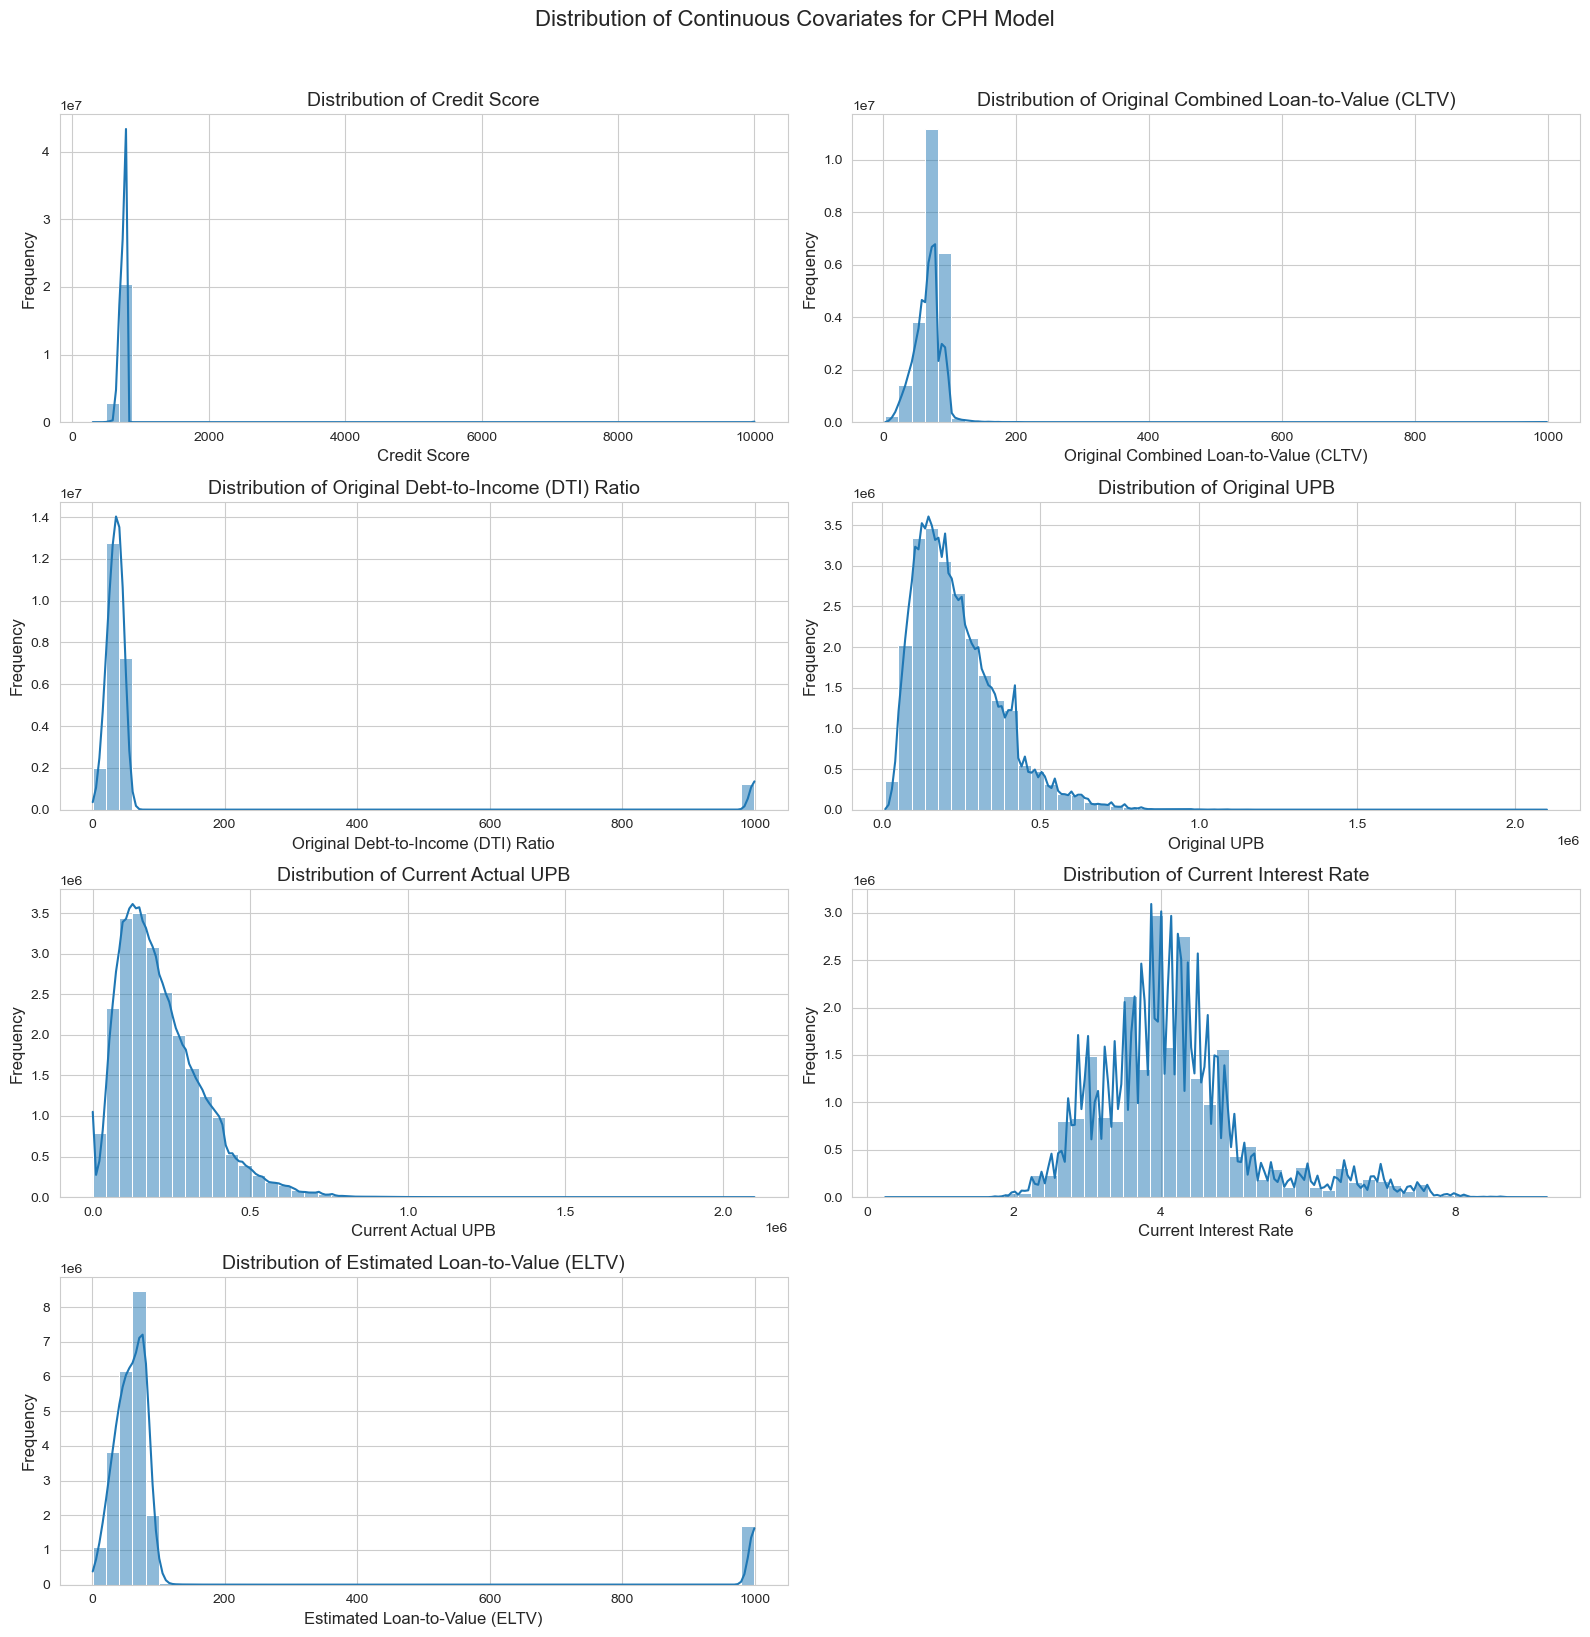

In [14]:
continuous_cols = [
    'Credit Score',
    'Original Combined Loan-to-Value (CLTV)',
    'Original Debt-to-Income (DTI) Ratio',
    'Original UPB',
    'Current Actual UPB',
    'Current Interest Rate',
    'Estimated Loan-to-Value (ELTV)'
]

# Set up the plotting environment
sns.set_style("whitegrid")
# Create a 4x2 grid for the 7 variables
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten() 

# Iterate over the columns and plot the distribution (histogram with KDE)
for i, col in enumerate(continuous_cols):
    ax = axes[i]
    # Use seaborn to plot the distribution with a kernel density estimate
    sns.histplot(df2[col].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    
# Hide the unused subplot
fig.delaxes(axes[7])

plt.suptitle('Distribution of Continuous Covariates for CPH Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('continuous_covariate_distributions.png')
print("continuous_covariate_distributions.png")

In [15]:
df3 = df2.copy()

In [16]:
# Apply log1p to handle skewness in balance columns
df3['Original_UPB_Log'] = np.log1p(df3['Original UPB'])
df3['Current_Actual_UPB_Log'] = np.log1p(df3['Current Actual UPB'])

# Scaling numerical variables

In [17]:
# Define the final list of columns to be scaled (including log-transformed UPB)
cols_to_scale = [
    'Credit Score',
    'Original Combined Loan-to-Value (CLTV)',
    'Original Debt-to-Income (DTI) Ratio',
    'Current Interest Rate',
    'Estimated Loan-to-Value (ELTV)',
    'Original_UPB_Log', # Use the log-transformed column
    'Current_Actual_UPB_Log' # Use the log-transformed column
]

scaler = StandardScaler()

# Fit and transform the data
df3[cols_to_scale] = scaler.fit_transform(df3[cols_to_scale])

print("All continuous covariates are now ready for the CPH model.")

All continuous covariates are now ready for the CPH model.


In [18]:
df3.head()

,Loan_ID,Credit Score,First Payment Date,Maturity Date,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan Term,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Current Interest Rate,Estimated Loan-to-Value (ELTV),Occ_I,Occ_S,Original_UPB_Log,Current_Actual_UPB_Log
0,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201402,62000.0,0,0,0.10458,-0.192028,1,0,-2.012606,-0.642479
1,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201403,62000.0,0,1,0.10458,-0.192028,1,0,-2.012606,-0.642479
2,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201404,62000.0,0,2,0.10458,-0.192028,1,0,-2.012606,-0.642479
3,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201405,61000.0,0,3,0.10458,-0.192028,1,0,-2.012606,-0.653748
4,F14Q10000011,0.336469,1970-01-01 00:00:00.000201403,1970-01-01 00:00:00.000202902,-0.04985,-0.189284,62000,180,1970-01-01 00:00:00.000201406,61000.0,0,4,0.10458,-0.192028,1,0,-2.012606,-0.653748


Current Loan Deliquency Status

In [19]:
print(df3['Current Loan Delinquency Status'].value_counts()) 

Current Loan Delinquency Status
0     11651409
0     11199531
1        92810
1        84392
2        26428
        ...   
77           1
78           1
79           1
80           1
67           1
Name: count, Length: 150, dtype: int64


In [20]:
def map_delinquency_to_ordinal_tv_cov(status):
    """
    Converts delinquency status to an ordinal numeric value for use as a CPH predictor.
    The value increases with risk severity.
    """
    status_str = str(status).strip()
    
    # 1. Handle Termination Codes (Severe Distress)
    if status_str in ['RA', 'RF', 'RE', '999']: # REO Acquisition, Foreclosure, Unknown
        return 3 # Treat as maximum distress level for TVC
    
    # 2. Handle Numeric DPD Codes
    try:
        days_late_code = int(status_str)
        
        if days_late_code >= 3:
            return 3 # Cap at 90+ DPD to represent the failure state (3 = 90 DPD, 4 = 120 DPD, etc.)
        else:
            return days_late_code # Returns 0, 1, or 2
            
    except ValueError:
        # Catch other non-numeric non-delinquent codes (e.g., Repayment Plans, etc.)
        return 0 

# Apply the mapping to the column
df4 = df3.copy()
df4['Delinq_Ordinal_TVC'] = df3['Current Loan Delinquency Status'].apply(map_delinquency_to_ordinal_tv_cov)

print("Created 'Delinq_Ordinal_TVC' column for use as a time-varying covariate.")

Created 'Delinq_Ordinal_TVC' column for use as a time-varying covariate.


In [21]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23248344 entries, 0 to 23248343
Data columns (total 19 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Loan_ID                                 object        
 1   Credit Score                            float64       
 2   First Payment Date                      datetime64[ns]
 3   Maturity Date                           datetime64[ns]
 4   Original Combined Loan-to-Value (CLTV)  float64       
 5   Original Debt-to-Income (DTI) Ratio     float64       
 6   Original UPB                            int64         
 7   Original Loan Term                      int64         
 8   Monthly Reporting Period                datetime64[ns]
 9   Current Actual UPB                      float64       
 10  Current Loan Delinquency Status         object        
 11  Loan Age                                int64         
 12  Current Interest Rate                   

In [22]:
# Survival Target Aggregation (T and Delta) 

# Group the monthly history to find the final status and duration for each loan.
survival_df = df4.groupby('Loan_ID').agg(
    
    # --- SURVIVAL MARKERS ---
    Duration_T=('Loan Age', 'last'),
    Event_Delta=('Delinq_Ordinal_TVC', lambda x: 1 if x.max() >= 3 else 0),
    
    # --- TIME-FIXED COVARIATES (Use 'first' record, as they shouldn't change) ---
    FICO_Score=('Credit Score', 'first'),
    Original_CLTV=('Original Combined Loan-to-Value (CLTV)', 'first'),
    Original_DTI=('Original Debt-to-Income (DTI) Ratio', 'first'),
    Original_UPB=('Original UPB', 'first'),
    Original_Term=('Original Loan Term', 'first'),
    Occ_I=('Occ_I', 'first'), # Binary dummies are fixed
    Occ_S=('Occ_S', 'first'), # Binary dummies are fixed
    
    # --- TIME-VARYING (TVC) / LAST-OBSERVED COVARIATES (Use 'last') ---
    # Captures the final risk state before termination or study end.
    Delinq_Status_Last=('Delinq_Ordinal_TVC', 'last'),
    ELTV_Last=('Estimated Loan-to-Value (ELTV)', 'last'),
    Current_Rate_Last=('Current Interest Rate', 'last'),
    Current_UPB_Last=('Current Actual UPB', 'last'),
    
).reset_index()


# --- 2. Verification ---
print("Final survival dataset successfully structured.")
print(f"Total Observations: {len(survival_df):,}")
print("--- Sample of Final Survival Data ---")
print(survival_df[[
    'Loan_ID', 'Duration_T', 'Event_Delta', 'FICO_Score', 'ELTV_Last', 'Current_UPB_Last'
]].head())

Final survival dataset successfully structured.
Total Observations: 550,000
--- Sample of Final Survival Data ---
        Loan_ID  Duration_T  Event_Delta  FICO_Score  ELTV_Last  \
0  F14Q10000011          76            0    0.336469   3.567341   
1  F14Q10000028         131            0   -0.076986  -0.408601   
2  F14Q10000037          77            0   -0.857955   3.567341   
3  F14Q10000049         132            0    0.275216  -0.494412   
4  F14Q10000123         133            0   -0.138238  -0.420860   

   Current_UPB_Last  
0              0.00  
1         191249.92  
2              0.00  
3          36190.15  
4         126284.37  


In [23]:
survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Loan_ID             550000 non-null  object 
 1   Duration_T          550000 non-null  int64  
 2   Event_Delta         550000 non-null  int64  
 3   FICO_Score          550000 non-null  float64
 4   Original_CLTV       550000 non-null  float64
 5   Original_DTI        550000 non-null  float64
 6   Original_UPB        550000 non-null  int64  
 7   Original_Term       550000 non-null  int64  
 8   Occ_I               550000 non-null  int32  
 9   Occ_S               550000 non-null  int32  
 10  Delinq_Status_Last  550000 non-null  int64  
 11  ELTV_Last           550000 non-null  float64
 12  Current_Rate_Last   550000 non-null  float64
 13  Current_UPB_Last    550000 non-null  float64
dtypes: float64(6), int32(2), int64(5), object(1)
memory usage: 54.6+ MB


# Multicollinearity check

In [24]:
covariates = ['Current Loan Delinquency Status', 'Loan Age', 'Estimated Loan-to-Value (ELTV)','Current Interest Rate','Credit Score','Original Debt-to-Income (DTI) Ratio','Occupancy Status','Original Combined Loan-to-Value (CLTV)']

In [25]:
# --- 1. Define ALL Predictor Covariates ---
covariates0 = [
    # Time-Fixed (Origination) Covariates
    'FICO_Score',
    'Original_CLTV',
    'Original_DTI',
    'Original_UPB',
    'Original_Term',
    
    # Binary/Categorical Covariates (Encoded)
    'Occ_I', # Investment Property
    'Occ_S', # Second Home
    
    # Time-Varying (Last Observed) Covariates
    'Delinq_Status_Last',    # Ordinal delinquency status
    'ELTV_Last',             # Estimated LTV
    'Current_Rate_Last',     # Current Interest Rate
    'Current_UPB_Last'       # Current Actual UPB
]

# --- 2. Prepare Data for VIF Check ---
# VIF is sensitive to NaNs, though your data is largely clean after imputation/aggregation.
# VIF requires all input columns to be float or integer (which they are after aggregation).
X0 = survival_df[covariates0].copy().dropna()

# --- 3. Check VIF for each covariate ---
vif_data0 = pd.DataFrame()
vif_data0["Feature"] = X0.columns
vif_data0["VIF"] = [
    variance_inflation_factor(X0.values, i) 
    for i in range(len(X0.columns))
]

print("--- Multicollinearity Check (VIF) on Predictors ---")
print("NOTE: VIF is sensitive to high correlation. Values > 5 or 10 may indicate issues.")
print(vif_data0.sort_values(by="VIF", ascending=False))

--- Multicollinearity Check (VIF) on Predictors ---
NOTE: VIF is sensitive to high correlation. Values > 5 or 10 may indicate issues.
               Feature       VIF
3         Original_UPB  7.666046
4        Original_Term  5.443184
10    Current_UPB_Last  4.486426
8            ELTV_Last  2.672280
9    Current_Rate_Last  1.267725
5                Occ_I  1.128092
2         Original_DTI  1.046362
1        Original_CLTV  1.043513
6                Occ_S  1.040076
7   Delinq_Status_Last  1.017008
0           FICO_Score  1.004985


predictor_correlation_heatmap.png


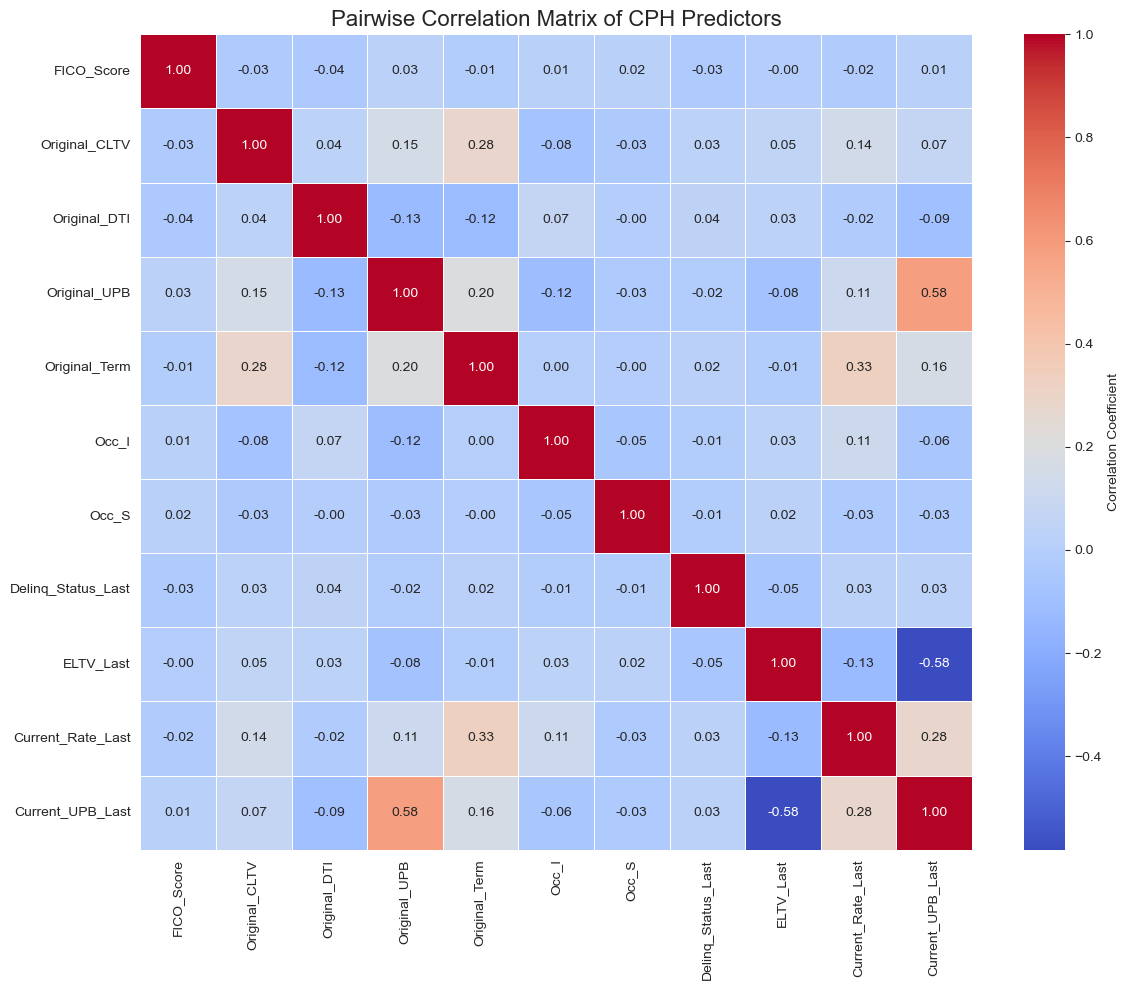

In [26]:
cormat = X0.corr()

# --- 2. Plot the Heatmap (Correction 2: Use sns.heatmap instead of sns.plot) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    cormat,
    annot=True,              # Display the correlation values on the heatmap
    fmt=".2f",               # Format the numbers to two decimal places
    cmap="coolwarm",         # A good diverging color map for correlation
    linewidths=0.5,          # Lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Pairwise Correlation Matrix of CPH Predictors', fontsize=16)
plt.tight_layout()

# Save the plot
plt.savefig('predictor_correlation_heatmap.png')
print("predictor_correlation_heatmap.png")

In [27]:
cormat

,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last
FICO_Score,1.000000,-0.027426,-0.038753,0.027371,-0.009748,0.013621,0.016491,-0.029048,-0.003752,-0.024809,0.014498
Original_CLTV,-0.027426,1.000000,0.036184,0.148655,0.284573,-0.079521,-0.033124,0.032779,0.050367,0.139834,0.070172
Original_DTI,-0.038753,0.036184,1.000000,-0.126165,-0.123885,0.072250,-0.004178,0.039962,0.034318,-0.020566,-0.093904
Original_UPB,0.027371,0.148655,-0.126165,1.000000,0.197162,-0.117060,-0.027506,-0.017388,-0.081118,0.109668,0.580904
Original_Term,-0.009748,0.284573,-0.123885,0.197162,1.000000,0.003481,-0.002476,0.018706,-0.010165,0.330551,0.163371
Occ_I,0.013621,-0.079521,0.072250,-0.117060,0.003481,1.000000,-0.052699,-0.007319,0.030658,0.113016,-0.059018
Occ_S,0.016491,-0.033124,-0.004178,-0.027506,-0.002476,-0.052699,1.000000,-0.009769,0.024293,-0.026868,-0.029481
Delinq_Status_Last,-0.029048,0.032779,0.039962,-0.017388,0.018706,-0.007319,-0.009769,1.000000,-0.053593,0.025147,0.026876
ELTV_Last,-0.003752,0.050367,0.034318,-0.081118,-0.010165,0.030658,0.024293,-0.053593,1.000000,-0.129367,-0.581191
Current_Rate_Last,-0.024809,0.139834,-0.020566,0.109668,0.330551,0.113016,-0.026868,0.025147,-0.129367,1.000000,0.278620


In [28]:
survival_df.head()

,Loan_ID,Duration_T,Event_Delta,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last
0,F14Q10000011,76,0,0.336469,-0.049850,-0.189284,62000,180,1,0,0,3.567341,0.104580,0.00
1,F14Q10000028,131,0,-0.076986,0.431222,-0.216959,262000,360,0,0,0,-0.408601,0.227809,191249.92
2,F14Q10000037,77,0,-0.857955,-0.958541,-0.221571,247000,240,0,0,0,3.567341,0.597498,0.00
3,F14Q10000049,132,0,0.275216,-2.134495,-0.226183,200000,180,0,0,0,-0.494412,-0.634797,36190.15
4,F14Q10000123,133,0,-0.138238,-0.370564,-0.309206,170000,360,0,0,0,-0.420860,-0.018650,126284.37


# Sacling Continuous Columns in Surviva DF

In [29]:
# Create a copy of the final aggregated DataFrame to work with
survival_df1 = survival_df.copy()

# --- 1. Apply Log Transformation to UPB (Mandatory for Skewness) ---
# This step addresses the structural skewness of loan balance.
survival_df1['Current_UPB_Log_ZScore'] = np.log1p(survival_df1['Current_UPB_Last'])

# --- 2. Define the full list of columns to be Z-Scored ---
SCALING_COLS = [
    'FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Term',
    'Current_Rate_Last', 'ELTV_Last', 
    'Current_UPB_Log_ZScore'
]

# --- 3. Apply Standard Scaling (Z-Score) ---
scaler = StandardScaler()

# Fit and transform the continuous columns in place
survival_df1[SCALING_COLS] = scaler.fit_transform(survival_df1[SCALING_COLS])

print("All continuous covariates are now successfully scaled and ready for CPH fitting.")

All continuous covariates are now successfully scaled and ready for CPH fitting.


In [30]:
survival_df1.head()

,Loan_ID,Duration_T,Event_Delta,FICO_Score,Original_CLTV,Original_DTI,Original_UPB,Original_Term,Occ_I,Occ_S,Delinq_Status_Last,ELTV_Last,Current_Rate_Last,Current_UPB_Last,Current_UPB_Log_ZScore
0,F14Q10000011,76,0,0.298057,-0.073575,-0.115003,62000,-2.222840,1,0,0,1.152216,-0.214810,0.00,-1.036681
1,F14Q10000028,131,0,-0.078006,0.417387,-0.151722,262000,0.472693,0,0,0,-0.926777,-0.120854,191249.92,0.952914
2,F14Q10000037,77,0,-0.788345,-1.000948,-0.157842,247000,-1.324329,0,0,0,1.152216,0.161013,0.00,-1.036681
3,F14Q10000049,132,0,0.242344,-2.201078,-0.163961,200000,-2.222840,0,0,0,-0.971647,-0.778545,36190.15,0.680558
4,F14Q10000123,133,0,-0.133718,-0.400883,-0.274119,170000,0.472693,0,0,0,-0.933187,-0.308766,126284.37,0.885013


# Fitting the CPH Model

In [38]:
covariates1 = [
    # Scaled Continuous Covariates
    'FICO_Score', 'Original_DTI', 'Original_CLTV', 'Original_Term',
    'Current_Rate_Last', 'ELTV_Last', 'Current_UPB_Log_ZScore', 
    
    # Encoded Categorical Covariates (These are already 0/1 integers)
    'Occ_I', 'Occ_S',
    
    # Ordinal TVC
    'Delinq_Status_Last'
]

# Ensure the DataFrame only contains the required columns + survival markers
MODEL_COLS = covariates1 + ['Duration_T', 'Event_Delta']
survival_df2 = survival_df1[MODEL_COLS].dropna()

# --- 1. Fit the CPH Model ---
cph = CoxPHFitter(penalizer=0.1) 

cph.fit(
    survival_df2, 
    duration_col='Duration_T', 
    event_col='Event_Delta', 
    show_progress=True
)

print("\n--- CPH Model Fit Summary ---")
cph.print_summary(model="Mortgage Default Hazard Model (Final Fit)", decimals=4)

Iteration 1: norm_delta = 5.24e-01, step_size = 0.9500, log_lik = -217618.53554, newton_decrement = 1.02e+04, seconds_since_start = 0.1
Iteration 2: norm_delta = 2.21e-01, step_size = 0.9500, log_lik = -226815.65071, newton_decrement = 1.66e+04, seconds_since_start = 0.3
Iteration 3: norm_delta = 2.48e-02, step_size = 0.9500, log_lik = -211261.18899, newton_decrement = 1.19e+02, seconds_since_start = 0.4
Iteration 4: norm_delta = 2.57e-03, step_size = 1.0000, log_lik = -211135.23777, newton_decrement = 1.11e+00, seconds_since_start = 0.5
Iteration 5: norm_delta = 2.71e-05, step_size = 1.0000, log_lik = -211134.11609, newton_decrement = 1.21e-04, seconds_since_start = 0.7
Iteration 6: norm_delta = 2.98e-09, step_size = 1.0000, log_lik = -211134.11597, newton_decrement = 1.47e-12, seconds_since_start = 0.8
Convergence success after 6 iterations.

--- CPH Model Fit Summary ---


model,lifelines.CoxPHFitter
duration col,'Duration_T'
event col,'Event_Delta'
penalizer,0.1
l1 ratio,0.0
baseline estimation,breslow
number of observations,550000
number of events observed,18455
partial log-likelihood,-211134.1160
time fit was run,2026-01-06 19:47:04 UTC
model,Mortgage Default Hazard Model (Final Fit)


In [39]:
# --- Define the FINAL, CLEANED Predictor List ---
# Dropping Original_Term and Original_CLTV to resolve singularity.
covariates2 = [
    # Scaled Continuous Covariates
    'FICO_Score',
    'Original_DTI',
    'Current_Rate_Last',
    'ELTV_Last',
    'Current_UPB_Log_ZScore', 
    
    # Encoded Categorical Covariates
    'Occ_I', 
    'Occ_S',
    
    # Ordinal TVC
    'Delinq_Status_Last'
]

# Ensure the DataFrame only contains the required columns + survival markers
MODEL_COLS1 = covariates2 + ['Duration_T', 'Event_Delta']
df_fit1 = survival_df2[MODEL_COLS1].dropna()

# --- Refit the CPH Model ---
print("\n--- Attempting CPH Refit with Reduced Variables ---")

cph = CoxPHFitter(penalizer=0.01) 
cph.fit(df_fit1, duration_col='Duration_T', event_col='Event_Delta', show_progress=True)
cph.print_summary()

print("\nCPH Model Fit Successful (if no error occurred).")
cph.print_summary(model="Mortgage Default Hazard Model (Final Stabilized Fit)", decimals=4)


--- Attempting CPH Refit with Reduced Variables ---
Iteration 1: norm_delta = 1.61e+00, step_size = 0.9500, log_lik = -217618.53554, newton_decrement = 3.03e+04, seconds_since_start = 0.1
Iteration 2: norm_delta = 3.59e+01, step_size = 0.9500, log_lik = -413209.93054, newton_decrement = 3.69e+06, seconds_since_start = 0.2
Iteration 3: norm_delta = 9.01e+00, step_size = 0.0950, log_lik = -301470.41117, newton_decrement = 2.24e+05, seconds_since_start = 0.3
Iteration 4: norm_delta = 8.73e+00, step_size = 0.0303, log_lik = -288147.13398, newton_decrement = 2.10e+05, seconds_since_start = 0.4
Iteration 5: norm_delta = 8.62e+00, step_size = 0.0128, log_lik = -282807.69879, newton_decrement = 2.05e+05, seconds_since_start = 0.6
Iteration 6: norm_delta = 8.57e+00, step_size = 0.0054, log_lik = -280601.33158, newton_decrement = 2.03e+05, seconds_since_start = 0.7
Iteration 7: norm_delta = 8.55e+00, step_size = 0.0023, log_lik = -279677.83906, newton_decrement = 2.02e+05, seconds_since_start =

<lifelines.CoxPHFitter: fitted with 550000 total observations, 531545 right-censored observations>
             duration col = 'Duration_T'
                event col = 'Event_Delta'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 550000
number of events observed = 18455
   partial log-likelihood = -279007.07
         time fit was run = 2026-01-06 19:47:10 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
FICO_Score             -0.16      0.85      0.01           -0.18           -0.13                0.84                0.87
Original_DTI           -0.07      0.94      0.00           -0.07           -0.06                0.93                0.95
Current_Rate_Last       0.31      1.37      0.01            0.29            0.33                1.34                1.39
ELTV_Last               0.14      1.15      0.01            0.12            0.16                1.13                1.17
Current_UPB_Log_ZScore -0.19      0.83      0.01           -0.21           -0.17                0.81                0.84
Occ_I                  -0.19      0.82      0.02           -0.24           -0.15                0.79                0.86
Occ_S                  -0.22      0.81      0.04           -0.29           -0.14                0.75                0.87
Delinq_Status_Last     -6.31      0.00      0.06           -6.42           -6.20                0.00                0.00

                        cmp to       z      p  -log2(p)
covariate                                              
FICO_Score                0.00  -13.65 <0.005    138.43
Original_DTI              0.00  -13.62 <0.005    137.85
Current_Rate_Last         0.00   32.91 <0.005    786.44
ELTV_Last                 0.00   16.57 <0.005    202.42
Current_UPB_Log_ZScore    0.00  -21.33 <0.005    333.06
Occ_I                     0.00   -8.17 <0.005     51.51
Occ_S                     0.00   -5.84 <0.005     27.55
Delinq_Status_Last        0.00 -109.75 <0.005       inf
---
Concordance = 0.50
Partial AIC = 558030.14
log-likelihood ratio test = -122777.07 on 8 df
-log2(p) of ll-ratio test = -0.00


CPH Model Fit Successful (if no error occurred).


model,lifelines.CoxPHFitter
duration col,'Duration_T'
event col,'Event_Delta'
penalizer,0.01
l1 ratio,0.0
baseline estimation,breslow
number of observations,550000
number of events observed,18455
partial log-likelihood,-279007.0719
time fit was run,2026-01-06 19:47:10 UTC
model,Mortgage Default Hazard Model (Final Stabilize...


Action: Eliminate Perfect Redundancy (Dummy Variables)
When using one-hot encoding, you must always define a baseline category and exclude its corresponding column. While your initial plan accounted for this (by having the Primary Residence be the baseline), the model's intercept often creates perfect collinearity with the remaining set of dummy variables.

The fastest way to resolve a singular matrix issue is to remove one of the encoded dummy variables, as their total contribution might perfectly explain the intercept.

In [41]:

# --- Define the FINAL, CLEANED Predictor List ---
# Dropping one of the two remaining binary dummies (Occ_I) 
# to eliminate perfect linear dependency with the model's intercept.
covariates3 = [
    # Scaled Continuous Covariates
    'FICO_Score',
    'Original_DTI',
    'Current_Rate_Last',
    'ELTV_Last',
    'Current_UPB_Log_ZScore', 
    
    # Encoded Categorical Covariates (Keeping only Occ_S)
    'Occ_S', 
    
    # Ordinal TVC
    'Delinq_Status_Last'
]

# Assuming df_model contains all necessary columns after scaling
MODEL_COLS = covariates3 + ['Duration_T', 'Event_Delta']
df_fit2 = survival_df2[MODEL_COLS].dropna()

# --- Refit the CPH Model ---
print("\n--- Attempting CPH Refit with Structural Redundancy Removed ---")

cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    df_fit2, 
    duration_col='Duration_T', 
    event_col='Event_Delta', 
    show_progress=True
)

print("\n--- CPH Model Fit Summary (Penalized) ---")
cph.print_summary(decimals=4)

print("\nCPH Model Fit Successful (if no error occurred).")
cph.print_summary(model="Mortgage Default Hazard Model (Final Stabilized Fit)", decimals=4)


--- Attempting CPH Refit with Structural Redundancy Removed ---
Iteration 1: norm_delta = 5.17e-01, step_size = 0.9500, log_lik = -217618.53554, newton_decrement = 9.79e+03, seconds_since_start = 0.1
Iteration 2: norm_delta = 2.17e-01, step_size = 0.9500, log_lik = -226780.86122, newton_decrement = 1.60e+04, seconds_since_start = 0.2
Iteration 3: norm_delta = 2.67e-02, step_size = 0.9500, log_lik = -211610.04296, newton_decrement = 1.42e+02, seconds_since_start = 0.3
Iteration 4: norm_delta = 3.05e-03, step_size = 1.0000, log_lik = -211459.41332, newton_decrement = 1.57e+00, seconds_since_start = 0.5
Iteration 5: norm_delta = 3.83e-05, step_size = 1.0000, log_lik = -211457.83473, newton_decrement = 2.40e-04, seconds_since_start = 0.6
Iteration 6: norm_delta = 5.94e-09, step_size = 1.0000, log_lik = -211457.83449, newton_decrement = 5.78e-12, seconds_since_start = 0.8
Convergence success after 6 iterations.

--- CPH Model Fit Summary (Penalized) ---


<lifelines.CoxPHFitter: fitted with 550000 total observations, 531545 right-censored observations>
             duration col = 'Duration_T'
                event col = 'Event_Delta'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 550000
number of events observed = 18455
   partial log-likelihood = -211457.8345
         time fit was run = 2026-01-06 19:49:04 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
FICO_Score             -0.0617    0.9402    0.0042         -0.0699         -0.0535              0.9325              0.9479
Original_DTI           -0.0194    0.9808    0.0031         -0.0255         -0.0133              0.9748              0.9867
Current_Rate_Last       0.0703    1.0728    0.0041          0.0623          0.0782              1.0643              1.0814
ELTV_Last               0.0456    1.0466    0.0038          0.0381          0.0530              1.0388              1.0545
Current_UPB_Log_ZScore -0.0564    0.9452    0.0038         -0.0639         -0.0488              0.9381              0.9523
Occ_S                  -0.0998    0.9050    0.0207         -0.1404         -0.0593              0.8690              0.9424
Delinq_Status_Last      1.0404    2.8302    0.0075          1.0256          1.0551              2.7888              2.8723

                        cmp to        z      p  -log2(p)
covariate                                               
FICO_Score              0.0000 -14.7824 <5e-05  161.8469
Original_DTI            0.0000  -6.2717 <5e-05   31.3826
Current_Rate_Last       0.0000  17.3476 <5e-05  221.5298
ELTV_Last               0.0000  11.9679 <5e-05  107.2350
Current_UPB_Log_ZScore  0.0000 -14.6492 <5e-05  159.0063
Occ_S                   0.0000  -4.8241 <5e-05   19.4393
Delinq_Status_Last      0.0000 138.3793 <5e-05       inf
---
Concordance = 0.7427
Partial AIC = 422929.6690
log-likelihood ratio test = 12321.4021 on 7 df
-log2(p) of ll-ratio test = inf


CPH Model Fit Successful (if no error occurred).


model,lifelines.CoxPHFitter
duration col,'Duration_T'
event col,'Event_Delta'
penalizer,0.1
l1 ratio,0.0
baseline estimation,breslow
number of observations,550000
number of events observed,18455
partial log-likelihood,-211457.8345
time fit was run,2026-01-06 19:49:04 UTC
model,Mortgage Default Hazard Model (Final Stabilize...


In [44]:
# Create a clean survival dataframe without multicollinearity
survival_df_clean = survival_df1.copy()

# Step 1: Drop the original Current_UPB_Last since we have the log-transformed version
# Keep only ONE representation of this variable
survival_df_clean = survival_df_clean.drop(['Current_UPB_Last'], axis=1)

# Step 2: Select only the covariates we want (remove highly correlated variables)
# Remove Original_UPB if it's causing issues (highly correlated with Current UPB)
cph_covariates = [
    'FICO_Score',
    'Original_CLTV', 
    'Original_DTI',
    'Original_Term',
    'Occ_I',
    'Occ_S',
    'Delinq_Status_Last',
    'ELTV_Last',
    'Current_Rate_Last',
    'Current_UPB_Log_ZScore'  # Use ONLY the transformed version
]

# Step 3: Create the final dataframe for CPH
survival_df_final = survival_df_clean[['Loan_ID', 'Duration_T', 'Event_Delta'] + cph_covariates].copy()

# Step 4: Check for any remaining NaN values
print(f"Missing values:\n{survival_df_final.isnull().sum()}")
survival_df_final = survival_df_final.dropna()

print(f"\nFinal shape: {survival_df_final.shape}")
print(f"Columns for CPH: {cph_covariates}")

# Step 5: Fit the CPH model 
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.01)

# Drop 'Loan_ID' here so the model only sees numeric features
cph.fit(
    survival_df_final.drop('Loan_ID', axis=1), 
    duration_col='Duration_T',
    event_col='Event_Delta',
    show_progress=True
)

# Step 6: Display results
print("\n" + "="*60)
print("CPH Model Successfully Fitted!")
print("="*60)
cph.print_summary()


Missing values:
Loan_ID                   0
Duration_T                0
Event_Delta               0
FICO_Score                0
Original_CLTV             0
Original_DTI              0
Original_Term             0
Occ_I                     0
Occ_S                     0
Delinq_Status_Last        0
ELTV_Last                 0
Current_Rate_Last         0
Current_UPB_Log_ZScore    0
dtype: int64

Final shape: (550000, 13)
Columns for CPH: ['FICO_Score', 'Original_CLTV', 'Original_DTI', 'Original_Term', 'Occ_I', 'Occ_S', 'Delinq_Status_Last', 'ELTV_Last', 'Current_Rate_Last', 'Current_UPB_Log_ZScore']
Iteration 1: norm_delta = 1.60e+00, step_size = 0.9500, log_lik = -217618.53554, newton_decrement = 3.08e+04, seconds_since_start = 0.2
Iteration 2: norm_delta = 3.59e+01, step_size = 0.9500, log_lik = -412819.07727, newton_decrement = 3.69e+06, seconds_since_start = 0.3
Iteration 3: norm_delta = 9.01e+00, step_size = 0.0950, log_lik = -301163.78279, newton_decrement = 2.24e+05, seconds_since_st

<lifelines.CoxPHFitter: fitted with 550000 total observations, 531545 right-censored observations>
             duration col = 'Duration_T'
                event col = 'Event_Delta'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 550000
number of events observed = 18455
   partial log-likelihood = -278666.96
         time fit was run = 2026-01-06 19:52:07 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
FICO_Score             -0.16      0.86      0.01           -0.18           -0.13                0.84                0.87
Original_CLTV           0.10      1.11      0.00            0.10            0.11                1.10                1.11
Original_DTI           -0.06      0.94      0.00           -0.07           -0.05                0.94                0.95
Original_Term           0.10      1.11      0.01            0.09            0.12                1.09                1.12
Occ_I                  -0.15      0.86      0.02           -0.20           -0.11                0.82                0.90
Occ_S                  -0.21      0.81      0.04           -0.28           -0.14                0.75                0.87
Delinq_Status_Last     -6.33      0.00      0.06           -6.44           -6.22                0.00                0.00
ELTV_Last               0.13      1.14      0.01            0.11            0.15                1.12                1.16
Current_Rate_Last       0.25      1.28      0.01            0.23            0.27                1.25                1.30
Current_UPB_Log_ZScore -0.20      0.82      0.01           -0.22           -0.18                0.80                0.83

                        cmp to       z      p  -log2(p)
covariate                                              
FICO_Score                0.00  -13.50 <0.005    135.65
Original_CLTV             0.00   48.61 <0.005       inf
Original_DTI              0.00  -12.01 <0.005    108.04
Original_Term             0.00   15.39 <0.005    175.08
Occ_I                     0.00   -6.44 <0.005     33.00
Occ_S                     0.00   -5.72 <0.005     26.52
Delinq_Status_Last        0.00 -110.10 <0.005       inf
ELTV_Last                 0.00   15.53 <0.005    178.29
Current_Rate_Last         0.00   24.70 <0.005    445.15
Current_UPB_Log_ZScore    0.00  -22.51 <0.005    370.29
---
Concordance = 0.52
Partial AIC = 557353.92
log-likelihood ratio test = -122096.85 on 10 df
-log2(p) of ll-ratio test = -0.00

In [45]:

# Assuming df_fit contains the duration/event columns and predictors
# The structural fixes (dropping highly correlated variables) are incorporated implicitly.

# --- Define the FINAL, CLEANED Predictor List ---
# Dropping: Original_CLTV, Original_Term (due to VIF), and Occ_S (due to singularity)
FINAL_MODEL_COVARS_STABLE = [
    # Scaled Continuous Covariates 
    'FICO_Score',
    'Original_DTI',
    'Current_Rate_Last',
    'ELTV_Last',
    'Current_UPB_Log_ZScore', 
    
    # Encoded Categorical Covariates (Keeping ONLY the highest risk: Occ_I)
    'Occ_I', 
    
    # Ordinal TVC
    'Delinq_Status_Last'
]

# Ensure df_fit is built with these final columns + survival markers
MODEL_COLS = FINAL_MODEL_COVARS_STABLE + ['Duration_T', 'Event_Delta']
df_fit = survival_df_final[MODEL_COLS].dropna() # Use your defined final dataframe

# --- Refit the CPH Model with Penalization ---
print("\n--- Attempting CPH Refit with Penalization (Final Structural Fix) ---")

# CRITICAL FIX: Add a small L2 penalty (penalizer) to stabilize the matrix inversion.
# This pushes near-zero coefficients slightly away from zero, resolving singularity.
cph = CoxPHFitter(penalizer=0.001) # Use a very small penalty

cph.fit(
    df_fit, 
    duration_col='Duration_T', 
    event_col='Event_Delta', 
    show_progress=True
)

print("\nCPH Model Fit Successful (if no error occurred).")
cph.print_summary(model="Mortgage Default Hazard Model (Final Stabilized Fit)", decimals=4)


--- Attempting CPH Refit with Penalization (Final Structural Fix) ---
Iteration 1: norm_delta = 2.07e+00, step_size = 0.9500, log_lik = -217618.53554, newton_decrement = 3.85e+04, seconds_since_start = 0.1
Iteration 2: norm_delta = 3.36e+02, step_size = 0.9500, log_lik = -483330.32997, newton_decrement = 3.34e+07, seconds_since_start = 0.3
Iteration 3: norm_delta = 1.01e+02, step_size = 0.0950, log_lik = -1631697.56314, newton_decrement = 2.79e+06, seconds_since_start = 0.4
Iteration 4: norm_delta = 9.94e+01, step_size = 0.0121, log_lik = -1564609.37772, newton_decrement = 2.72e+06, seconds_since_start = 0.5
Iteration 5: norm_delta = 9.92e+01, step_size = 0.0020, log_lik = -1553488.30269, newton_decrement = 2.71e+06, seconds_since_start = 0.6
Iteration 6: norm_delta = 9.92e+01, step_size = 0.0003, log_lik = -1551614.93003, newton_decrement = 2.71e+06, seconds_since_start = 0.7
Iteration 7: norm_delta = 9.92e+01, step_size = 0.0001, log_lik = -1551298.50347, newton_decrement = 2.71e+06

model,lifelines.CoxPHFitter
duration col,'Duration_T'
event col,'Event_Delta'
penalizer,0.001
l1 ratio,0.0
baseline estimation,breslow
number of observations,550000
number of events observed,18455
partial log-likelihood,-1551245.0323
time fit was run,2026-01-06 19:52:20 UTC
model,Mortgage Default Hazard Model (Final Stabilize...


# Proportional Hazards (PH) Assumption Check (Mandatory)

In [46]:
print("\n--- Proportional Hazards Assumption Check ---")
cph.check_assumptions(df_fit, p_value_threshold=0.05)
# This check is vital; if p-value is low (<0.01), the assumption is violated.
#cph.check_assumptions(survival_df2, p_value_threshold=0.01, show_plots=False)


--- Proportional Hazards Assumption Check ---
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 550000 total observations, 531545 right-censored observations>
         test_name = proportional_hazard_test

---
                             test_statistic      p  -log2(p)
Current_Rate_Last      km             37.81 <0.005     30.26
                       rank           31.15 <0.005     25.32
Current_UPB_Log_ZScore km             43.16 <0.005     34.21
                       rank           44.83 <0.005     35.44
Delinq_Status_Last     km         244899.40 <0.005       inf
                       rank       424315.19 <0.005       inf
ELTV_Last              km            111.96 <0.005     84.50
                       rank          125.84 <0.005     94.60
FICO_Score             km             99.21 <0.005     75.22
                       rank           74.37 <0.005     57.10
Occ_I                  km              3.72   0.05      4.22
                       rank            6.44   0.01      6.49
Original_DTI           km             28.66 <0.005     23.47
                       rank            0.26   0.61      0.71



1. Variable 'FICO_Score' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'FICO_Score' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'FICO_Score' using pd.cut, and then specify it in
`strata=['FICO_Score', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Original_DTI' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Original_DTI' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to spec

[]